In [1]:
%load_ext autoreload
%autoreload 2

from IPython.core.debugger import set_trace
from config import parse_args
args = parse_args("",None)
import sys
#sys.path.insert(0, args.worktree)
#sys.path.insert(0,  "/home/kim2712/Desktop/research/BGAN/BGAN")
sys.path.insert(0, "/Users/kjungeum/PycharmProjects/BGAN/BGAN")

In [2]:
! pwd

/Users/kjungeum/PycharmProjects/BGAN/exp_controller/yuexi_deep_design


In [3]:
from BGAN_deep_critic import DBGAN_mix as BGAN
#from BGAN_double_deep_critic import double_DBGAN as BGAN
#from BGAN import BGAN

from _data.gaussian_conjugate import posterior_sampler, forward_sampler, X_forward_sampler
from os.path import join
import pathlib

In [4]:
HPARAM = {"nu":args.nu, "sigma0_sq":args.sigma0_sq, 
          "mu0":args.mu0,"kappa":args.kappa}

args.epoch = 30
args.n_sample=20

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import seaborn as sns

In [6]:
print(torch.backends.mps.is_available())  # Should return True on M1/M2/M3/M4 Macs

# Move tensors to GPU
device = torch.device("mps")

True


In [7]:

nsample =args.n_sample
x_obs=1

observed_data=np.array([x_obs for _ in range(nsample)])
theta, sigma_sq = posterior_sampler(X = observed_data,
                                        batch_size=300,
                                        h_param = HPARAM)
true = np.stack([theta,sigma_sq],1)
x_true = torch.tensor(np.repeat(observed_data.reshape(1, nsample, 1), 300, axis=0), dtype=torch.float).to(device)


In [8]:
def plot(self):
    n_row,n_col = 1,2
    fig,axis = plt.subplots(n_row, n_col, figsize=(4*n_col,4*n_row), sharex=True, sharey=True)
    #set_trace()
    sample = self.sampler(observed_data.reshape(1,-1,1), 300, 
                            shaper = lambda X: torch.from_numpy(X).float().repeat(300, 1,1))
    #sample = self.sampler(observed_data.reshape(1,-1), 300,shaper = lambda X: torch.from_numpy(X).float().repeat(300, 1))
    
    sample += torch.randn(size=sample.shape)*0.0001 

    ax = axis[0] 
    sns.kdeplot(x=true[:,0], y=true[:,1], ax=ax, fill=True, color="orange")
    ax = axis[1] 
    sns.kdeplot(x=true[:,0], y=true[:,1], ax=ax, fill=True, 
                color="orange", alpha= 0.3) 
    sns.kdeplot(x=sample[:,0], y=sample[:,1], ax=ax, fill=False)
    plt.show()

In [13]:
def simulator(batch_size, np_random=None):
        n_samples=args.n_sample
        h_param = HPARAM
        Theta,X =  forward_sampler(n = n_samples, 
                        batch_size=batch_size,
                        h_param=h_param, as_torch = True, np_random=np_random,
                                   device = device)
        return Theta, X.unsqueeze(-1)
    
method = BGAN(simulator=simulator, 
             epoch=args.epoch,
             x_dim = 1,
             x_length = args.n_sample,
             theta_dim=2,n_iter=100,
             batch_size = args.batch_size,
             f1_dim =args.n_sample, f2_dim=0, Q_freq = 0, 
             critic_lr = 0.0003, generator_lr = 0.0003, inner_lr = 0.001,
              
              factor=128, f1_layers =2,
             common_factor=128,
              common_layers = 2,hidden_layers=2,
              d_hidden=128,
              device=device

              )
#factor: 16, 32, 64, 128
#f1_layers: 0,1,2
#common_layers: 2,3
#hidden_layers: 0,1,2
#d_hidden: 16, 32, 64, 128
#common_factor: 16 32 64 128

In [14]:
method.generator, method.critic

(Generator(
   (layers): ModuleList(
     (0): Linear(in_features=22, out_features=128, bias=True)
     (1): Linear(in_features=128, out_features=128, bias=True)
     (2): Linear(in_features=128, out_features=2, bias=True)
   )
   (activation): LeakyReLU(negative_slope=0.1)
   (ss): Auto_ss(
     (f1): DeepSets(
       (common_feature_net): MLP(
         (non_linear): LeakyReLU(negative_slope=0.1)
         (dropout): Dropout(p=0, inplace=False)
         (layers): ModuleList(
           (0): Linear(in_features=3, out_features=128, bias=True)
           (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
           (3): Linear(in_features=128, out_features=20, bias=True)
         )
       )
       (next_net): MLP(
         (non_linear): LeakyReLU(negative_slope=0.1)
         (dropout): Dropout(p=0, inplace=False)
         (layers): ModuleList(
           (0): Linear(in_features=20, out_features=128, bias=True)
           (1-2): 2 x Linear(in_features=128, out_features=128, bi

In [15]:
method.w_regul=0.1

Epoch 0
Epoch 1
Epoch 2
Epoch 3


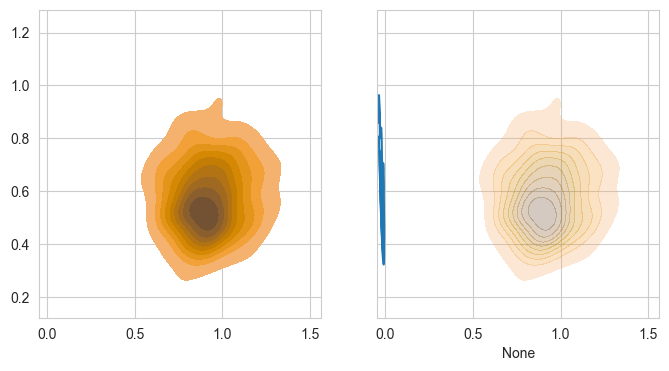

{'epoch': 3, 'iter': 47, 'mmd': 0.726, 'loss': -0.321}
Epoch 2
Epoch 3
Epoch 4
Epoch 5


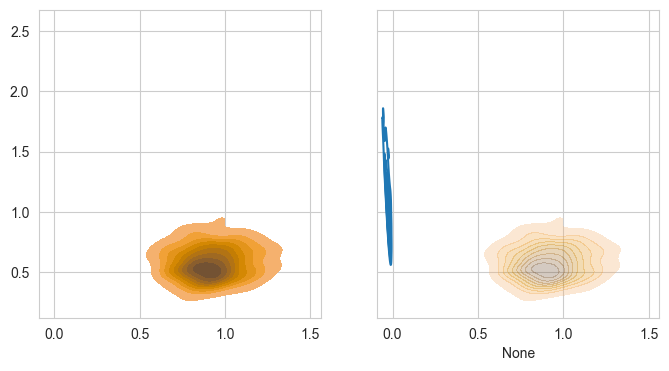

{'epoch': 5, 'iter': 47, 'mmd': 0.525, 'loss': -0.533}
Epoch 4
Epoch 5
Epoch 6
Epoch 7


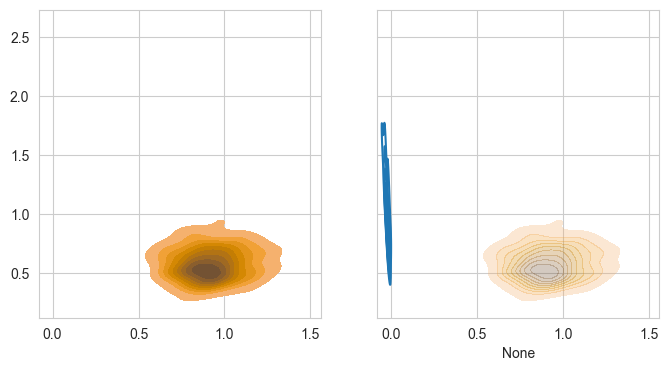

{'epoch': 7, 'iter': 47, 'mmd': 0.481, 'loss': -0.312}
Epoch 6
Epoch 7
Epoch 8
Epoch 9


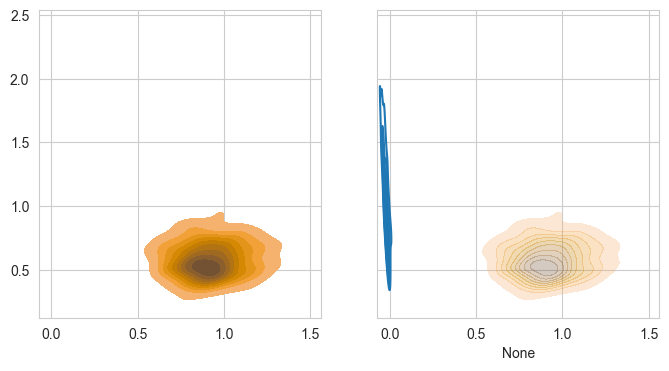

{'epoch': 9, 'iter': 47, 'mmd': 0.452, 'loss': -0.149}
Epoch 8
Epoch 9
Epoch 10
Epoch 11


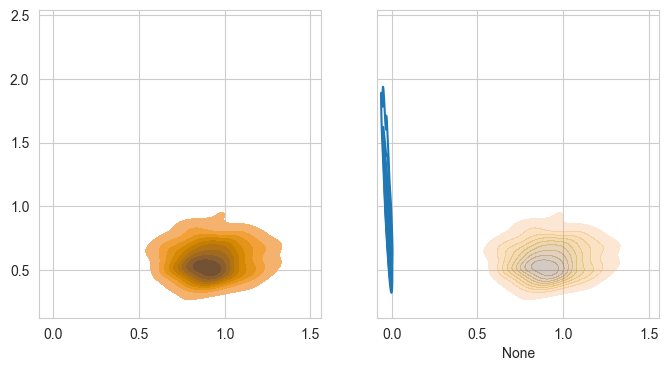

{'epoch': 11, 'iter': 47, 'mmd': 0.478, 'loss': -0.035}


In [17]:
for j in range(5):
    method.train(true_x=x_true, true_thetas=true,
        start_epoch=2*j, end_epoch=2*(j+1)+1, n_iter=50)
    plot(method)
    print(method.qualities[-1])

<AxesSubplot:>

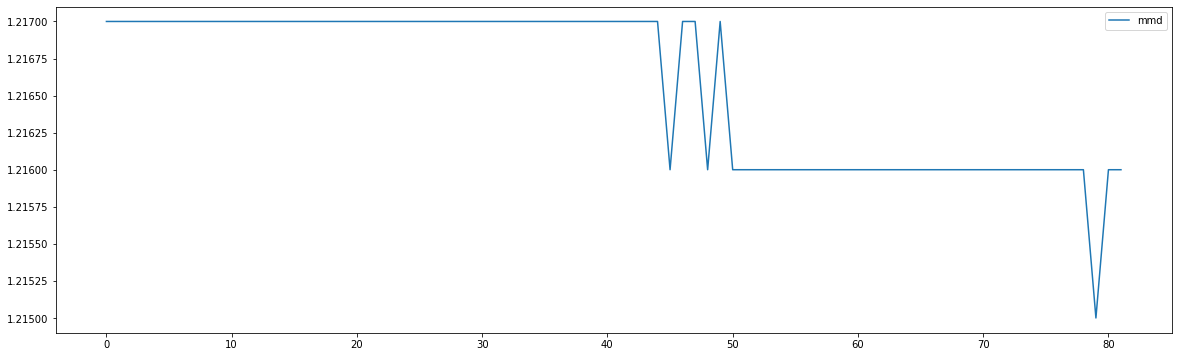

In [69]:
import pandas as pd
pd.DataFrame(method.qualities).plot(y="mmd", figsize=(20,6))

In [18]:
#method.save("./results/double_n8.net")

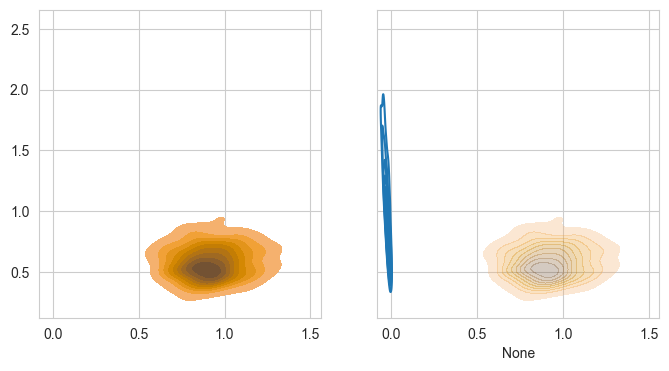

In [19]:
plot(method)